ARTI308 - Machine Learning

# Lab 3: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

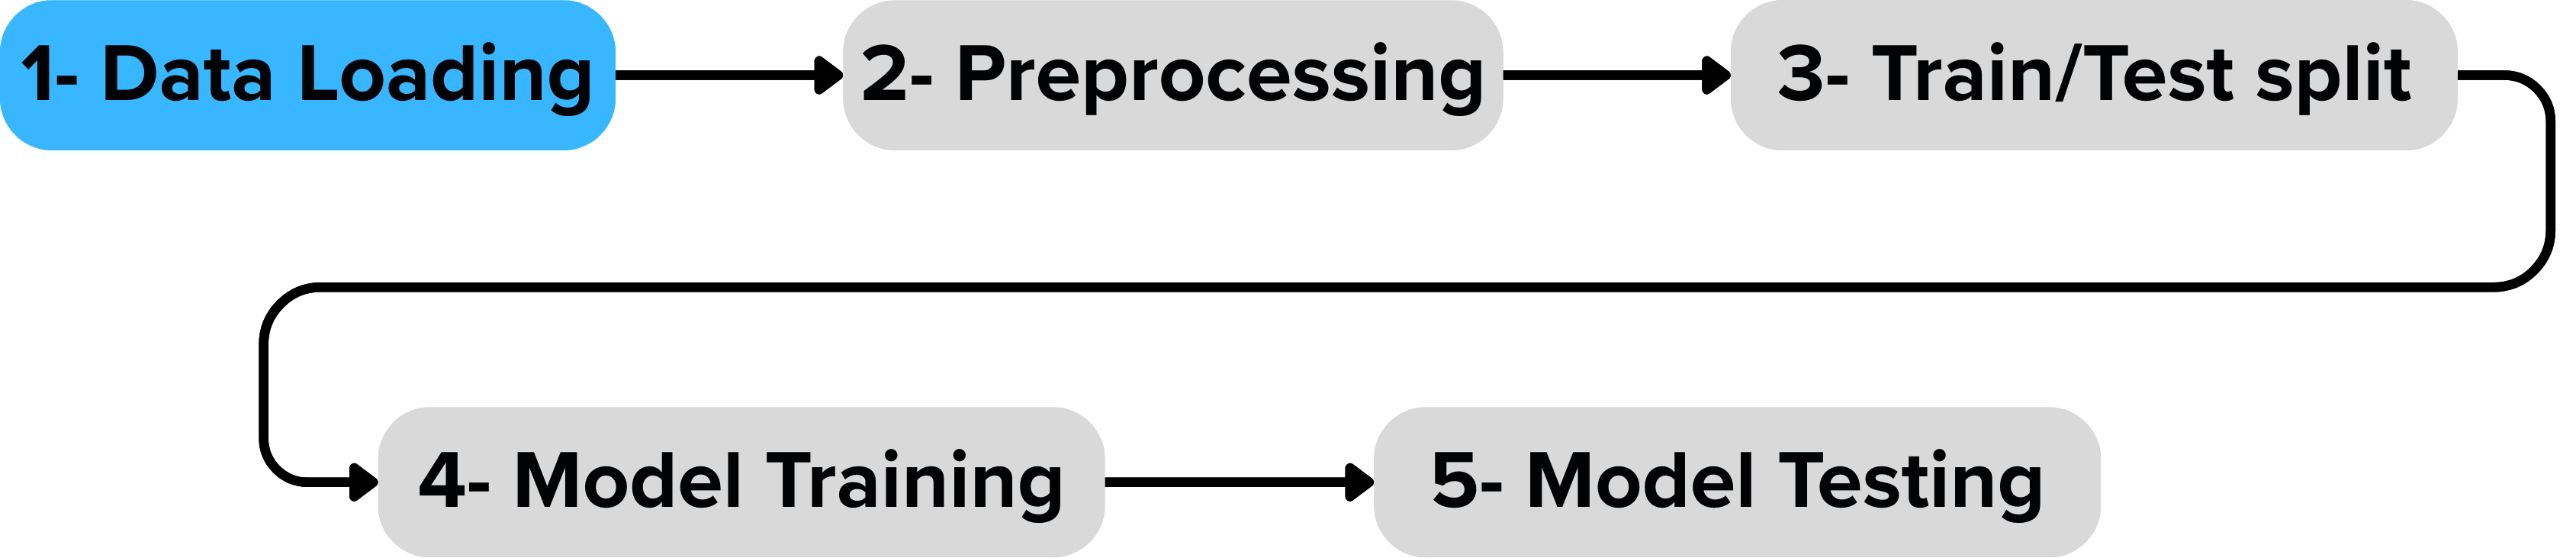

In [35]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [36]:
# Load Dataset

df = pd.read_csv("Exam_Score_Prediction.csv")

# Display first 5 rows
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


### Check Missing Values

In [37]:
# Check all values
print(df.isna())

       student_id    age  gender  course  study_hours  class_attendance  \
0           False  False   False   False        False             False   
1           False  False   False   False        False             False   
2           False  False   False   False        False             False   
3           False  False   False   False        False             False   
4           False  False   False   False        False             False   
...           ...    ...     ...     ...          ...               ...   
19995       False  False   False   False        False             False   
19996       False  False   False   False        False             False   
19997       False  False   False   False        False             False   
19998       False  False   False   False        False             False   
19999       False  False   False   False        False             False   

       internet_access  sleep_hours  sleep_quality  study_method  \
0                False        F

In [38]:
print(df.isna().sum())

student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64


### Check duplicate rows

In [39]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

### No. of rows and columns

In [40]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (20000, 13) 

number of rows:  20000
number of columns:  13


### Data type of columns

In [41]:
# viewing the data types of columns
df.dtypes

student_id            int64
age                   int64
gender                  str
course                  str
study_hours         float64
class_attendance    float64
internet_access         str
sleep_hours         float64
sleep_quality           str
study_method            str
facility_rating         str
exam_difficulty         str
exam_score          float64
dtype: object

### Descriptive summary Statistics

In [42]:
# Statistical summary
df.describe(include='all')

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
count,20000.000000,20000.000000,20000,20000,20000.000000,20000.000000,20000,20000.00000,20000,20000,20000,20000,20000.000000
unique,NaN,NaN,3,7,NaN,NaN,2,NaN,3,5,3,3,NaN
top,NaN,NaN,other,bca,NaN,NaN,yes,NaN,average,self-study,medium,moderate,NaN
freq,NaN,NaN,6726,2902,NaN,NaN,16988,NaN,6694,4079,6760,9878,NaN
mean,10000.504600,20.473300,NaN,NaN,4.007604,70.017365,NaN,7.00856,NaN,NaN,NaN,NaN,62.513225
std,5773.654959,2.284458,NaN,NaN,2.308313,17.282262,NaN,1.73209,NaN,NaN,NaN,NaN,18.908491
min,1.000000,17.000000,NaN,NaN,0.080000,40.600000,NaN,4.10000,NaN,NaN,NaN,NaN,19.599000
25%,5000.750000,18.000000,NaN,NaN,2.000000,55.100000,NaN,5.50000,NaN,NaN,NaN,NaN,48.800000
50%,10000.500000,20.000000,NaN,NaN,4.040000,69.900000,NaN,7.00000,NaN,NaN,NaN,NaN,62.600000
75%,15000.250000,22.000000,NaN,NaN,6.000000,85.000000,NaN,8.50000,NaN,NaN,NaN,NaN,76.300000


### Univariate Analysis

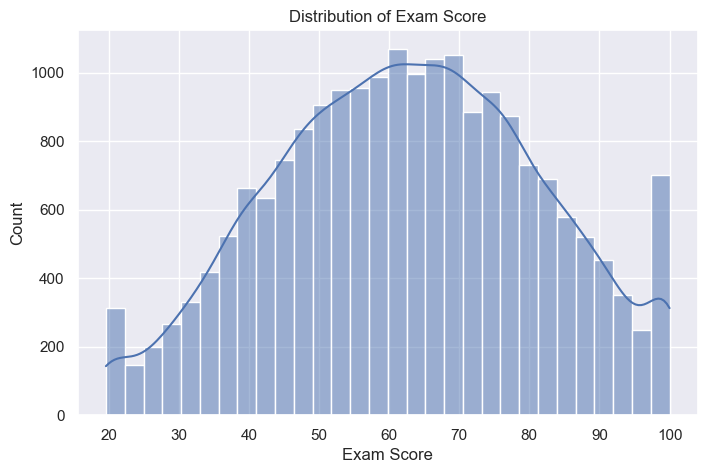

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(df['exam_score'], bins=30, kde=True)
plt.title("Distribution of Exam Score")
plt.xlabel("Exam Score")
plt.ylabel("Count")
plt.show()

- Shows how shipment sizes are distributed
- Right skew = many small shipments, few large ones

### Distribution of Stude Hours

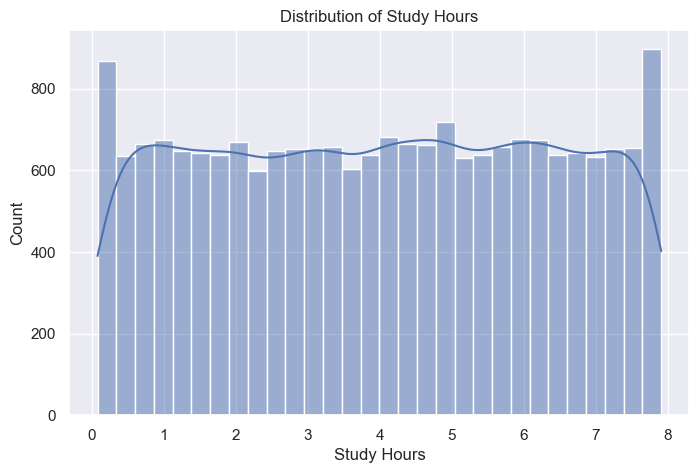

In [44]:
plt.figure(figsize=(8,5))
sns.histplot(df['study_hours'], bins=30, kde=True)
plt.title("Distribution of Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Count")
plt.show()

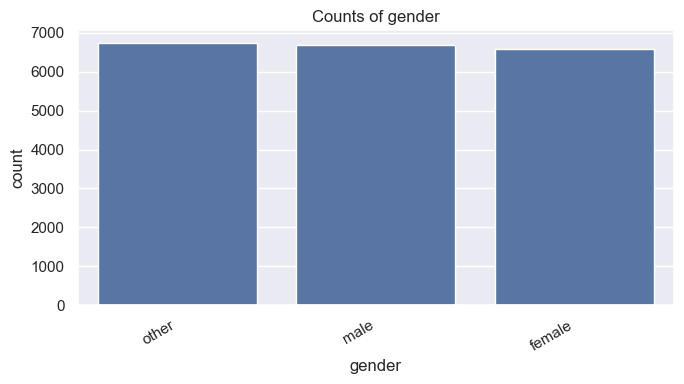

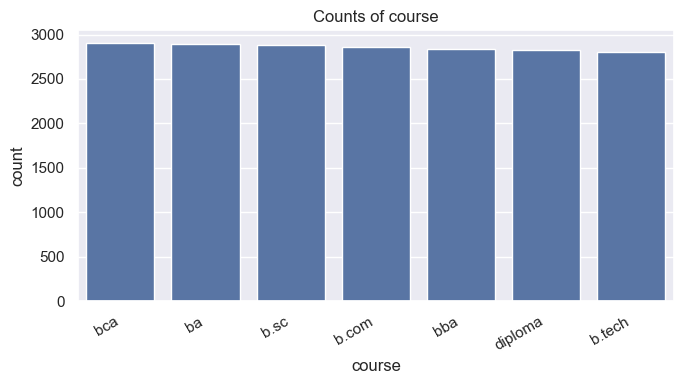

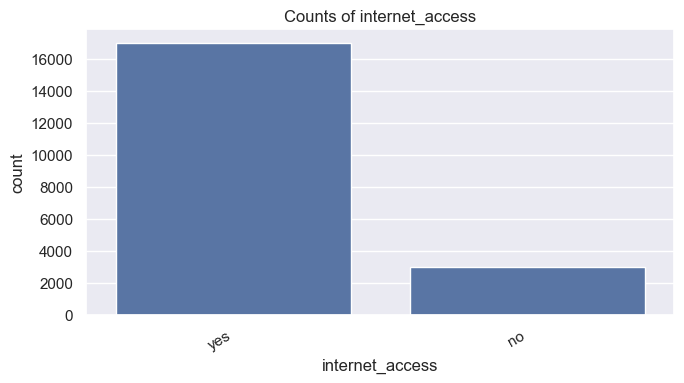

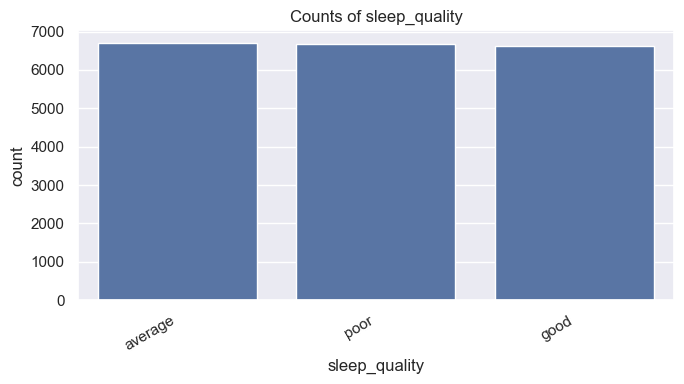

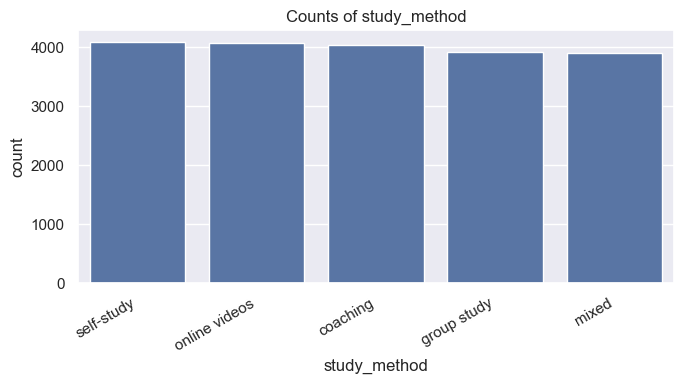

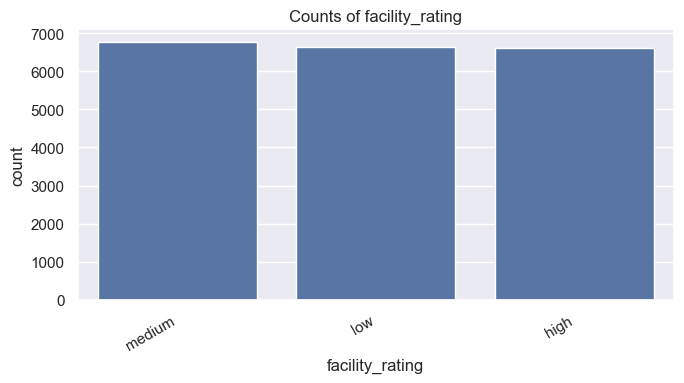

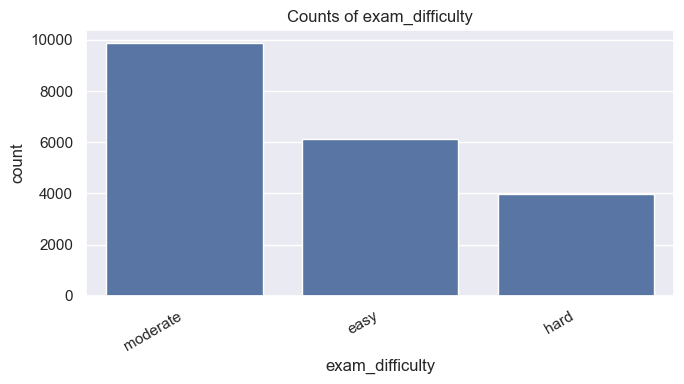

In [45]:
cat_cols = ['gender','course','internet_access','sleep_quality','study_method','facility_rating','exam_difficulty']
for col in cat_cols:
    plt.figure(figsize=(7,4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Counts of {col}")
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

## Bivariate Analysis

### Study Hours vs Exam Score

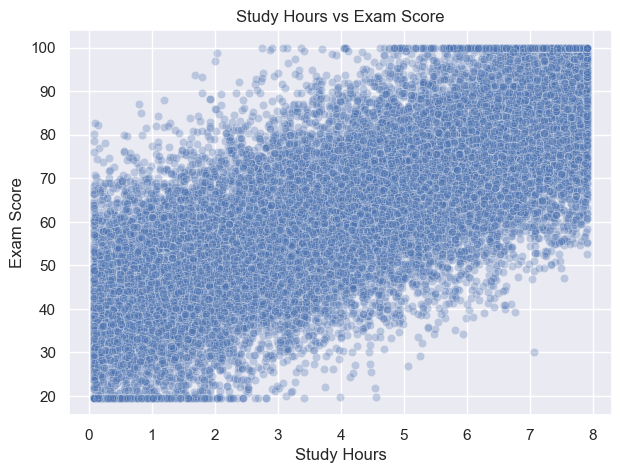

In [46]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='study_hours', y='exam_score', alpha=0.3)
plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.show()

### Class Attendance vs Exam Score

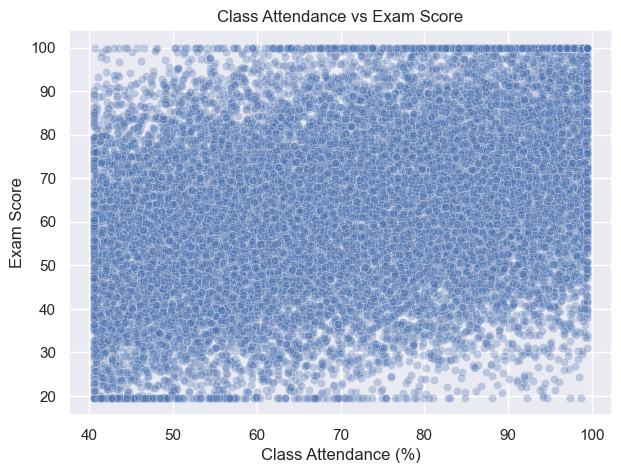

In [47]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='class_attendance', y='exam_score', alpha=0.3)
plt.title("Class Attendance vs Exam Score")
plt.xlabel("Class Attendance (%)")
plt.ylabel("Exam Score")
plt.show()

### Exam Score by Category

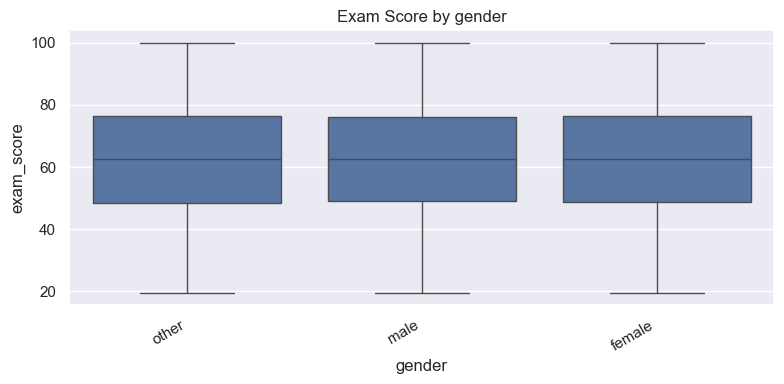

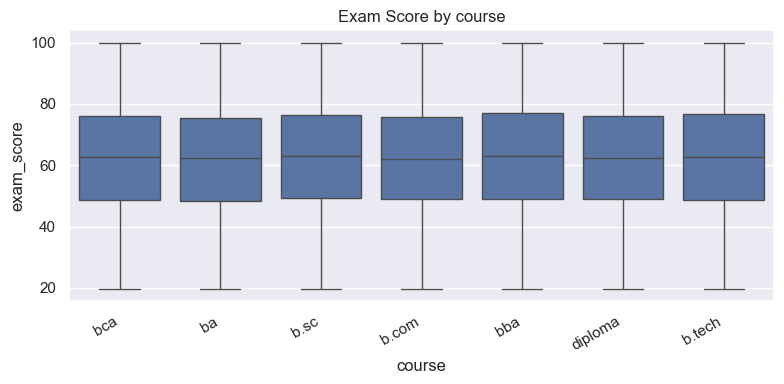

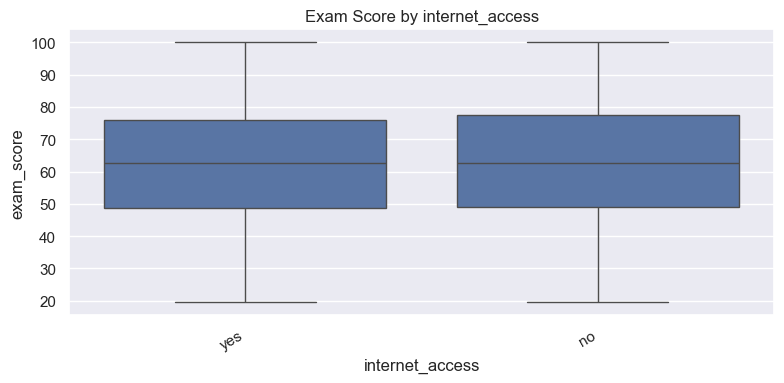

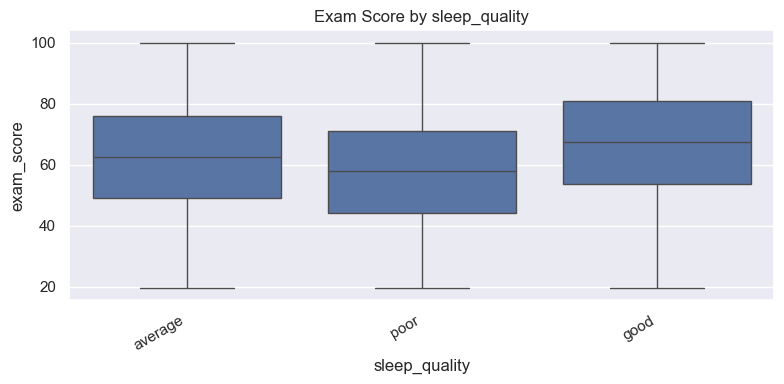

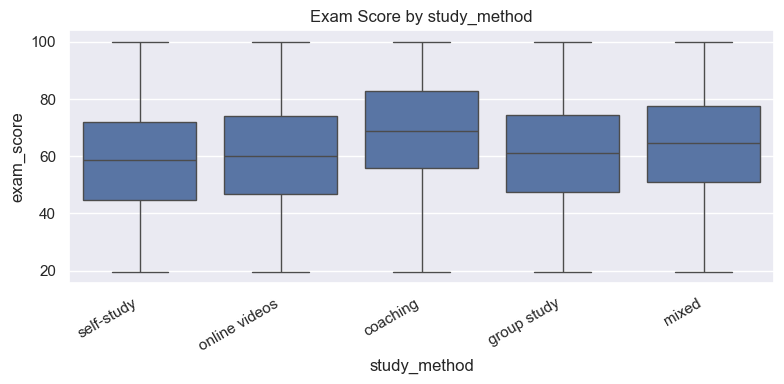

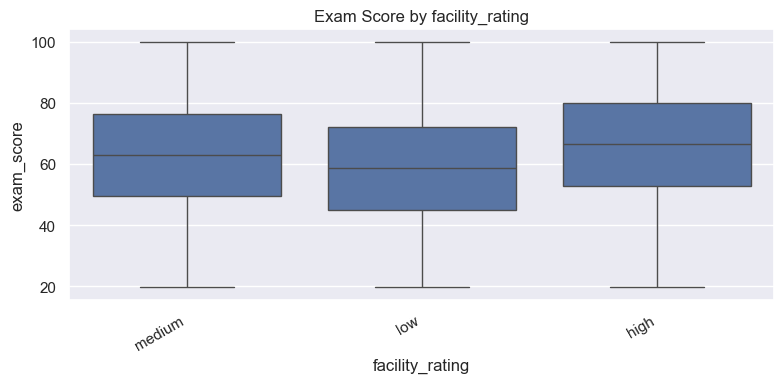

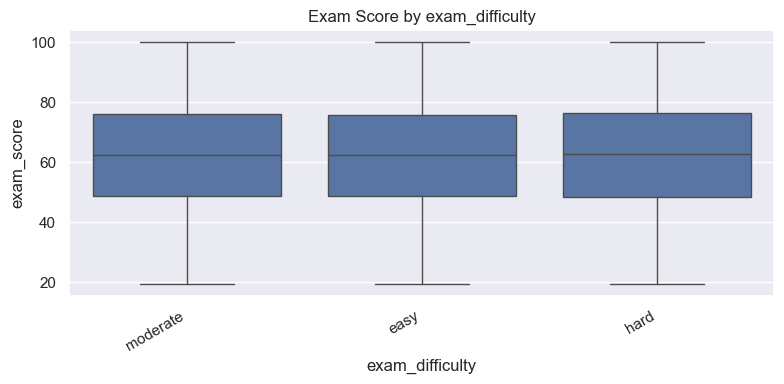

In [48]:
box_cols = ['gender','course','internet_access','sleep_quality','study_method','facility_rating','exam_difficulty']
for col in box_cols:
    plt.figure(figsize=(8,4))
    order = df[col].value_counts().index
    sns.boxplot(data=df, x=col, y='exam_score', order=order)
    plt.title(f"Exam Score by {col}")
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

Correlation Matrix

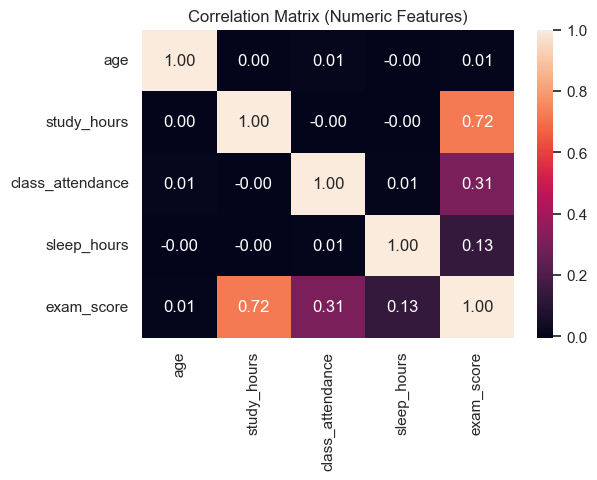

In [49]:
num_cols = ['age','study_hours','class_attendance','sleep_hours','exam_score']
corr = df[num_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

- Correlation close to 1 = strong positive relationship
- Close to 0 = weak relationship

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the dataset file with your notebook.


End of lab 3.

In [34]:
%pip install -U pandas seaborn numpy matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
